# 20 &middot; Quadratic (P2) finite elements in 3D

Tutorial [12](012_p2_finite_elements.ipynb) introduced quadratic (**P2**) triangles in 2D. Here the same
`simkit` P2 toolchain runs on **10-node tetrahedra**: a slender beam, clamped at one end, sags under its
own weight. P2 displacements vary quadratically inside each element, so a tet can bend and its faces
curve; on this bending-dominated cantilever that is the difference between a beam that droops and one
that locks. Only the operators change (one $F$ per cubature point, consistent mass and gravity); the
elastic energy, the pin and the Newton solver are the ordinary P1 code.

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import igl
import simkit
import utils
plt.rcParams["savefig.pad_inches"] = 0.25   # 3D axis labels sit outside the tight crop; leave room

NOTEBOOK = "020_p2_finite_elements_3d"                            # this file's name
RESULTS_DIR = utils.notebook_results_path(NOTEBOOK)# results/020_p2_finite_elements_3d/
MEDIA_DIR = "media"                                               # tracked copies for the website
# mesh: a long, slender brick along x, 5 tets per grid cube
NX, NY, NZ = 5, 3, 3                   # grid vertices along x, y, z
LENGTH, HEIGHT, DEPTH = 5.0, 0.4, 0.4  # beam size
# material and loads
MATERIAL = "macklin-mueller-neo-hookean"
YM, PR = 1.2e4, 0.45                   # Young's modulus, Poisson ratio
RHO = 1.0                              # density
GRAVITY = -9.8                         # acceleration along y
K_PIN = 1e8                            # soft-pin stiffness of the clamped x = min face
QUAD_ORDER = 2                         # P2 cubature order (4 points per tet)
# solvers
STATIC_ITERS, STATIC_TOL = 300, 1e-9   # Newton iterations / step tolerance for static equilibrium
DT = 0.02                              # backward-Euler timestep
N_STEPS = 70                           # timesteps of the release-from-rest run (1.4 s)
STEP_ITERS, STEP_TOL = 30, 1e-7        # Newton iterations / step tolerance per timestep
# gradient check
FD_STEP = 1e-6                         # central-difference step
FD_NOISE = 0.05                        # random perturbation of the check state
SEED = 0                               # random seed of the perturbation
# rendering
SUBDIV_STILL = 2                       # igl.upsample levels per curved P2 face in still images (16 triangles)
SUBDIV_VIDEO = 1                       # ... and in the video (4 triangles)
FRAME_STRIDE = 2                       # keep every 2nd timestep as a video frame
FPS = 18                               # video frame rate (about 0.7x real time)
VIEW = dict(elev=18, azim=-60)         # 3D camera for the deformed beam
MESH_VIEW = dict(elev=30, azim=-35)    # 3D camera for the rest-mesh screenshot

## 1 &middot; A tetrahedral beam, promoted to P2

`utils.tetrahedralized_grid` builds a linear tet mesh of the brick. `simkit.linear_to_quadratic_elements`
then adds one node at the midpoint of every edge and lists, per tet, its 4 corners followed by its 6 edge
midpoints (a **10-node** tet), and `simkit.gauss_legendre_quadrature` places cubature points (barycentric
coordinates plus physical weights) inside every tet. We also select the nodes of the clamped face
$x = x_\min$ and of the free tip $x = x_\max$.

In [2]:
X, T = utils.tetrahedralized_grid(NX, NY, NZ, width=LENGTH, height=HEIGHT, depth=DEPTH)
V2, T2 = simkit.linear_to_quadratic_elements(X, T)                    # corners first, then edge midpoints
bary, w = simkit.gauss_legendre_quadrature(X, T, QUAD_ORDER)          # (t, n_quad, 4), (t, n_quad)
n1, n2, dim = len(X), len(V2), X.shape[1]
pin1 = np.where(X[:, 0] <= X[:, 0].min() + 1e-9)[0]                   # clamped face, P1 nodes
pin2 = np.where(V2[:, 0] <= V2[:, 0].min() + 1e-9)[0]                 # clamped face, P2 nodes
tip1 = np.where(X[:, 0] >= X[:, 0].max() - 1e-9)[0]                   # free tip, P1 nodes
tip2 = np.where(V2[:, 0] >= V2[:, 0].max() - 1e-9)[0]                 # free tip, P2 nodes
print(f"P1 (linear):    {n1:4d} nodes, {len(T)} tets ({T.shape[1]} nodes each), {n1 * dim} dofs, {len(pin1)} pinned")
print(f"P2 (quadratic): {n2:4d} nodes, {len(T2)} tets ({T2.shape[1]} nodes each), {n2 * dim} dofs, {len(pin2)} pinned")
print(f"cubature: {bary.shape[1]} points per tet, {bary.shape[0] * bary.shape[1]} in total")

P1 (linear):      45 nodes, 80 tets (4 nodes each), 135 dofs, 9 pinned
P2 (quadratic):  209 nodes, 80 tets (10 nodes each), 627 dofs, 25 pinned
cubature: 4 points per tet, 320 in total


The meshes, drawn by their surface triangles (`igl.boundary_facets`), with the clamped face as blue
squares. Left: the P1 tets. Middle: the same tets with the P2 edge-midpoint nodes (orange); they are shared
by neighbouring tets, so the P2 mesh stays conforming. Right: the cubature points where $F$ is evaluated.

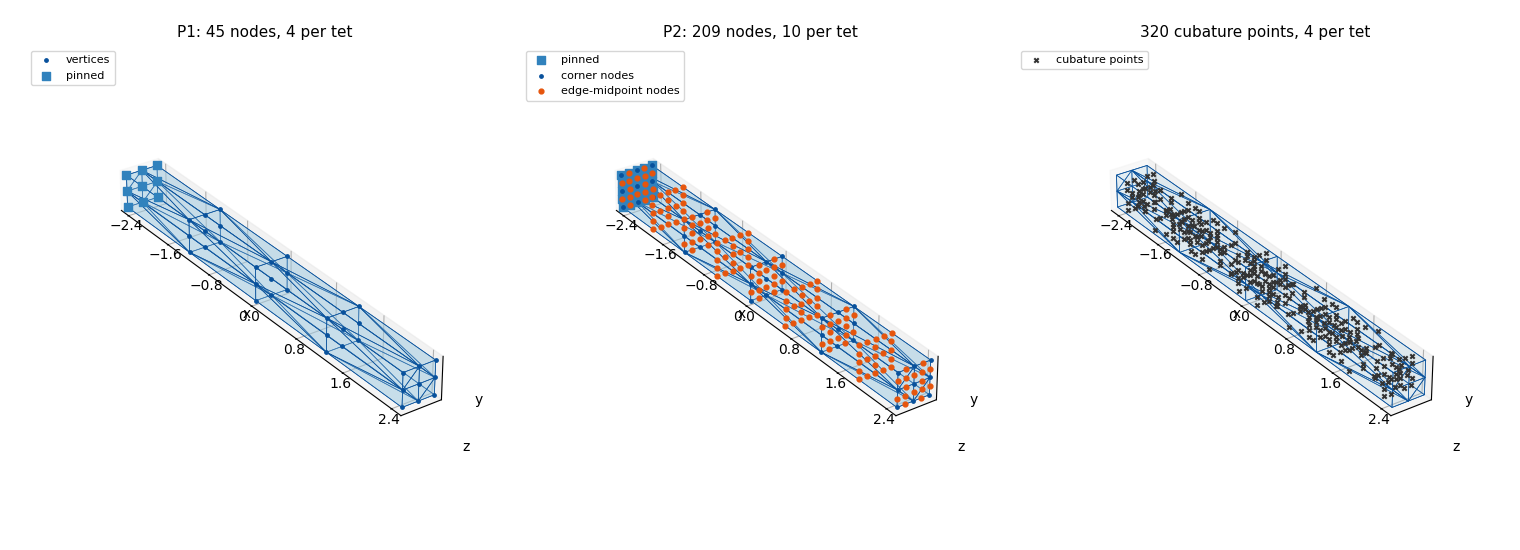

In [3]:
F_bnd, F_tet, _ = igl.boundary_facets(T)                              # surface triangles, and the tet of each
cub_rest = np.einsum("tqc,tcd->tqd", bary, X[T]).reshape(-1, dim)      # cubature points in the rest shape
lims = utils.auto_limits_3d([X], pad=0.05)

fig = plt.figure(figsize=(15, 5.2))
ax = fig.add_subplot(131, projection="3d")
utils.plot_mesh_y_up(ax, X, F_bnd, pins=pin1, lims=lims, title=f"P1: {n1} nodes, 4 per tet", **MESH_VIEW)
ax.legend(loc="upper left", fontsize=8)
ax = fig.add_subplot(132, projection="3d")
utils.plot_mesh_y_up(ax, V2, F_bnd, pins=pin2, lims=lims, show_vertices=False,
                     title=f"P2: {n2} nodes, 10 per tet", **MESH_VIEW)
utils.scatter_y_up(ax, V2[:n1], s=6, color=utils.MESH_EDGE, label="corner nodes")
utils.scatter_y_up(ax, V2[n1:], s=12, color=utils.HANDLE_C, label="edge-midpoint nodes")
ax.legend(loc="upper left", fontsize=8)
ax = fig.add_subplot(133, projection="3d")
utils.plot_mesh_y_up(ax, X, F_bnd, lims=lims, show_vertices=False, alpha=0.12,
                     title=f"{len(cub_rest)} cubature points, {bary.shape[1]} per tet", **MESH_VIEW)
utils.scatter_y_up(ax, cub_rest, s=10, marker="x", color="0.2", label="cubature points")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "beam_meshes.png"),
                              copy_to=os.path.join(MEDIA_DIR, "020_beam_meshes.png"))
plt.show()

## 2 &middot; Quadrature and the P2 operators

A P1 tet has one constant $F$. P2 shape-function gradients are linear in position, so $F$ varies inside
the tet and the energy integral becomes a cubature sum (below). `deformation_jacobian_p2` is still a
constant sparse matrix; it maps nodal positions to one $F$ per cubature point, and the weights `w` replace
`vol`. `p2_massmatrix` and `p2_gravity_force` build the consistent mass and gravity over the 10-node set.
The printout checks $F = I$ at rest, and that mass and weight integrate to $\rho V$ and $\rho g V$ for both
element types.

$$E_{P1} = \sum_t \text{vol}_t\, \psi(F_t), \qquad E_{P2} = \sum_t \sum_q w_{tq}\, \psi(F_{tq}).$$

In [4]:
ops_p1 = dict(nodes=X, pins=pin1,
              J=simkit.deformation_jacobian(X, T),                                        # one F per tet
              vol=simkit.volume(X, T),                                                    # tet volumes
              M=sp.sparse.kron(simkit.massmatrix(X, T, rho=RHO), sp.sparse.eye(dim)).tocsc(),
              f_g=simkit.gravity_force(X, T, a=GRAVITY, rho=RHO).reshape(-1, 1))
ops_p2 = dict(nodes=V2, pins=pin2,
              J=simkit.deformation_jacobian_p2(V2, T2, bary, w),                          # one F per cubature point
              vol=w.reshape(-1, 1),                                                       # cubature weights
              M=sp.sparse.kron(simkit.p2_massmatrix(V2, T2, bary, w, rho=RHO), sp.sparse.eye(dim)).tocsc(),
              f_g=simkit.p2_gravity_force(V2, T2, bary, w, a=GRAVITY, rho=RHO).reshape(-1, 1))
volume = ops_p1["vol"].sum()                                              # total rest volume
for name, ops in (("P1", ops_p1), ("P2", ops_p2)):
    F_rest = (ops["J"] @ ops["nodes"].reshape(-1, 1)).reshape(-1, dim, dim)
    print(f"{name}: {len(F_rest):3d} F blocks, F == I at rest: {np.allclose(F_rest, np.eye(dim))}, "
          f"mass = {ops['M'].sum() / dim:.4f}, weight = {ops['f_g'].reshape(-1, dim)[:, 1].sum():.4f}")
print(f"expected: rho V = {RHO * volume:.4f}, rho g V = {RHO * GRAVITY * volume:.4f}")

P1:  80 F blocks, F == I at rest: True, mass = 0.8000, weight = -7.8400
P2: 320 F blocks, F == I at rest: True, mass = 0.8000, weight = -7.8400
expected: rho V = 0.8000, rho g V = -7.8400


### Where does gravity act? A 3D surprise

The consistent load on node $i$ is $f_i = \rho g \int N_i \, dV$. Over a tet of volume $V_e$,
$\int L_i(2L_i - 1)\,dV = -V_e/20$ for a corner and $\int 4L_aL_b\,dV = V_e/5$ for a midpoint, so gravity
pushes every P2 **corner node up** while the midpoints carry 120% of the weight (for 2D P2 triangles the
corner integral is exactly zero). The plot shows this nodal load field against each node's $x$ position,
with P1 for reference; the totals, in the legend, are all $\rho g V$.

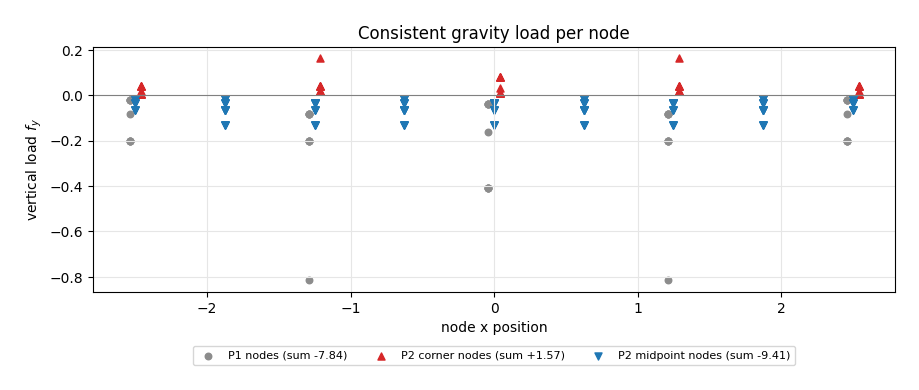

In [5]:
fy1 = ops_p1["f_g"].reshape(-1, dim)[:, 1]
fy2 = ops_p2["f_g"].reshape(-1, dim)[:, 1]
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.axhline(0.0, color="0.5", lw=0.8)
ax.scatter(X[:, 0] - 0.04, fy1, s=22, color="0.55", label=f"P1 nodes (sum {fy1.sum():.2f})")
ax.scatter(V2[:n1, 0] + 0.04, fy2[:n1], s=26, marker="^", color="#d62728",
           label=f"P2 corner nodes (sum {fy2[:n1].sum():+.2f})")
ax.scatter(V2[n1:, 0], fy2[n1:], s=26, marker="v", color="#1f77b4",
           label=f"P2 midpoint nodes (sum {fy2[n1:].sum():.2f})")
ax.set_xlabel("node x position")
ax.set_ylabel(r"vertical load $f_y$")
ax.set_title("Consistent gravity load per node")
ax.grid(True, color="0.9", linewidth=0.8)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), fontsize=8, ncol=3)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "gravity_load.png"),
                              copy_to=os.path.join(MEDIA_DIR, "020_gravity_load.png"))
plt.show()

## 3 &middot; The beam system

The potential is the neo-Hookean elastic energy, the soft pin $\tfrac12 x^\top Q x + b^\top x$ of the
clamped face, and gravity $-f_g^\top x$. `beam_system` builds it from whichever operator set it is handed
(it cannot tell P1 from P2); the unchanged `elastic_*_x` functions simply treat every cubature point as a
pseudo-element. Passing the previous positions `x_curr, x_prev` adds the backward-Euler inertia
$\tfrac{1}{2h^2}\lVert x - \tilde x\rVert_M^2$ with $\tilde x = 2x_\text{curr} - x_\text{prev}$, i.e. one
implicit time step with the consistent mass matrix.

In [6]:
def beam_system(nodes, pins, J, vol, M, f_g, x_curr=None, x_prev=None):
    """Elastic + soft pin + gravity (+ backward-Euler inertia if x_curr, x_prev are given)."""
    n, dim = nodes.shape
    mu, lam = simkit.ympr_to_lame(YM, PR)
    mu = np.full((vol.shape[0], 1), mu)
    lam = np.full((vol.shape[0], 1), lam)
    Q_pin, b_pin = simkit.dirichlet_penalty(pins, nodes[pins], n, K_PIN)
    dynamic = x_curr is not None

    def energy_func(x):
        E_elastic = simkit.energies.elastic_energy_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        E_pin = simkit.energies.quadratic_energy(x, Q_pin, b_pin)
        E_gravity = -(f_g.T @ x).item()
        E_inertia = simkit.energies.kinetic_energy_be(x, x_curr, x_prev, M, DT) if dynamic else 0.0
        E_total = E_elastic + E_pin + E_gravity + E_inertia
        return E_total

    def gradient_func(x):
        g_elastic = simkit.energies.elastic_gradient_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        g_pin = simkit.energies.quadratic_gradient(x, Q_pin, b_pin)
        g_gravity = -f_g
        g_inertia = simkit.energies.kinetic_gradient_be(x, x_curr, x_prev, M, DT) if dynamic else 0.0
        g_total = g_elastic + g_pin + g_gravity + g_inertia
        return g_total

    def hessian_func(x):
        H_elastic = simkit.energies.elastic_hessian_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL, psd=True)
        H_pin = simkit.energies.quadratic_hessian(Q_pin)
        H_inertia = simkit.energies.kinetic_hessian_be(M, DT) if dynamic else 0.0
        H_total = H_elastic + H_pin + H_inertia
        return H_total

    return energy_func, gradient_func, hessian_func

Before solving anything, `gradient_func` is checked against a central-difference gradient of
`energy_func` (`simkit.gradient_cfd`) at a randomly perturbed state, with inertia switched on. Relative
errors around $10^{-7}$ or below (the stiff pin limits the finite-difference precision) mean the analytic
gradient is right.

In [7]:
rng = np.random.default_rng(SEED)
for name, ops in (("P1", ops_p1), ("P2", ops_p2)):
    x_rest = ops["nodes"].reshape(-1, 1)
    energy_func, gradient_func, _ = beam_system(**ops, x_curr=x_rest, x_prev=x_rest)
    x_test = x_rest + FD_NOISE * rng.standard_normal(x_rest.shape)
    g_fd = simkit.gradient_cfd(lambda y: np.array(energy_func(y.reshape(-1, 1))), x_test.ravel(), FD_STEP)
    g = gradient_func(x_test).ravel()
    print(f"{name}: relative gradient error = {np.linalg.norm(g - g_fd) / np.linalg.norm(g):.1e}")

P1: relative gradient error = 9.1e-08


P2: relative gradient error = 2.4e-07


## 4 &middot; Clamp one end and solve the static equilibrium

Newton's method (PSD-projected Hessian, backtracking line search) minimizes the static potential of the
P2 beam, starting from the straight rest shape. The printout gives the tip drop, the largest nodal
displacement and the smallest $\det F$ over all cubature points: the free tip drops by more than half the
beam's length, and no element inverts. (The huge negative potential is explained with the Newton plot in
section 6.)

In [8]:
energy_func, gradient_func, hessian_func = beam_system(**ops_p2)
x2, info2 = simkit.solvers.newton_solver(V2.reshape(-1, 1).copy(), energy_func, gradient_func, hessian_func,
                                         max_iter=STATIC_ITERS, tolerance=STATIC_TOL, return_info=True)
sol2 = x2.reshape(n2, dim)
F2 = (ops_p2["J"] @ x2).reshape(-1, dim, dim)                         # one F per cubature point
drop2 = V2[tip2, 1].mean() - sol2[tip2, 1].mean()
print(f"Newton iterations      : {info2['iters'] + 1}")
print(f"free-tip height        : {sol2[tip2, 1].mean():+.3f}   (rest {V2[tip2, 1].mean():+.3f}, drop {drop2:.3f})")
print(f"max nodal displacement : {np.linalg.norm(sol2 - V2, axis=1).max():.3f}")
print(f"min det(F)             : {np.linalg.det(F2).min():.3f}   (> 0: no inverted elements)")
print(f"potential at equilibrium: {energy_func(x2):.4e}")

Newton iterations      : 114
free-tip height        : -2.787   (rest -0.000, drop 2.787)
max nodal displacement : 2.986
min det(F)             : 0.963   (> 0: no inverted elements)
potential at equilibrium: -7.8625e+09


### Rendering P2 in 3D: truly curved faces

A P2 tet face is a curved quadratic patch through its 6 nodes (3 corners, 3 edge midpoints). For every
surface triangle from `igl.boundary_facets` we look up its midpoint nodes in `T2`, then evaluate the P2
triangle shape functions (`simkit.p2_shape_functions`) on an `igl.upsample`d reference triangle, which
samples the real curved surface. A P1 mesh has nothing to sample: its faces are flat.

In [9]:
TET_EDGES = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]         # simkit's order: T2[:, 4 + k] is edge k's midpoint
midpoint = {tuple(sorted((el[a], el[b]))): el[4 + k] for el in T2 for k, (a, b) in enumerate(TET_EDGES)}
FACES6 = np.array([[a, b, c,                                          # P2 triangle order: corners, then the
                    midpoint[tuple(sorted((a, b)))],                  # midpoints of edges (0,1), (1,2), (2,0)
                    midpoint[tuple(sorted((b, c)))],
                    midpoint[tuple(sorted((c, a)))]] for a, b, c in F_bnd])

def p2_patch_basis(levels):
    """P2 triangle basis W (samples x 6) on an upsampled reference triangle, and its sub-triangles."""
    ref_V, ref_F = igl.upsample(np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0]]), np.array([[0, 1, 2]]), levels)
    L = np.column_stack([1.0 - ref_V.sum(axis=1), ref_V])             # barycentric coordinates of the samples
    W = np.array([simkit.p2_shape_functions(Li, 3)[0] for Li in L])
    return W, ref_F

def p2_surface_samples(U2, W):
    """Nodal field U2 (n2, 3) evaluated at every sample of every curved boundary face: (faces, samples, 3)."""
    return np.einsum("sk,fkd->fsd", W, U2[FACES6])

def curved_surface(U2, W, ref_F):
    """The curved P2 boundary of positions U2 as small flat triangles (n_triangles, 3, 3)."""
    return p2_surface_samples(U2, W)[:, ref_F].reshape(-1, 3, 3)

W_still, ref_F_still = p2_patch_basis(SUBDIV_STILL)
W_video, ref_F_video = p2_patch_basis(SUBDIV_VIDEO)
print(f"{len(FACES6)} curved boundary faces, sampled with {len(ref_F_still)} (still) / {len(ref_F_video)} (video) triangles each")
rest_samples = p2_surface_samples(V2, W_still).reshape(-1, dim)
off_box = np.abs(np.abs(rest_samples) - np.array([LENGTH, HEIGHT, DEPTH]) / 2).min(axis=1)
print(f"at rest every sample lies on the flat brick faces (max distance {off_box.max():.1e})")

80 curved boundary faces, sampled with 16 (still) / 4 (video) triangles each
at rest every sample lies on the flat brick faces (max distance 0.0e+00)


The rest beam (faint) and the sagged equilibrium, drawn with its true curved P2 faces.

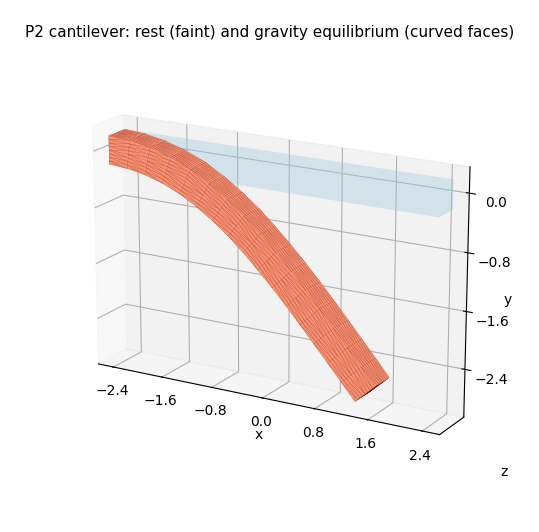

In [10]:
lims_static = utils.auto_limits_3d([X, sol2], pad=0.15)
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
utils.surface_y_up(ax, curved_surface(V2, W_still, ref_F_still), facecolor=utils.MESH_FACE, edgecolor="none", alpha=0.2)
utils.surface_y_up(ax, curved_surface(sol2, W_still, ref_F_still), facecolor="#fc9272",
                   edgecolor=(0.3, 0, 0, 0.25), lw=0.25, alpha=0.97)
utils.setup_axes_y_up(ax, lims_static, title="P2 cantilever: rest (faint) and gravity equilibrium (curved faces)", **VIEW)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "p2_beam_static.png"),
                              copy_to=os.path.join(MEDIA_DIR, "020_p2_beam_static.png"))
plt.show()

Two scalar fields on the equilibrium. Left: the displacement magnitude $\lVert u \rVert$, evaluated with
the P2 basis at every surface sample, so it varies smoothly across each face. Right: the elastic energy
density $\psi(F)$ averaged over each tet's cubature points (log scale). The strain energy is concentrated
at the clamped root, where the bending moment is largest; the outer half of the beam mostly rotates.

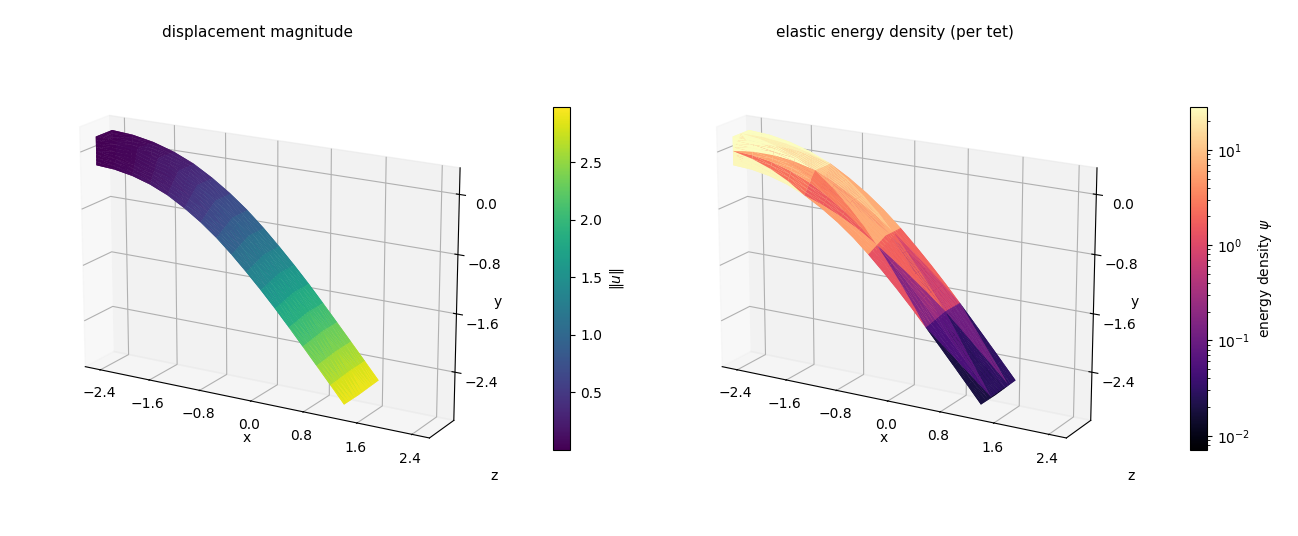

In [11]:
disp = np.linalg.norm(p2_surface_samples(sol2 - V2, W_still), axis=-1)            # (faces, samples)
disp_tri = disp[:, ref_F_still].mean(axis=-1).ravel()                             # per drawn triangle
mu0, lam0 = simkit.ympr_to_lame(YM, PR)
psi = simkit.energies.elastic_energy_element_F(F2, np.full((len(F2), 1), mu0), np.full((len(F2), 1), lam0), MATERIAL)
psi_tet = (w * psi.reshape(w.shape)).sum(axis=1) / w.sum(axis=1)                  # cubature-weighted tet average
psi_tri = np.repeat(psi_tet[F_tet], len(ref_F_still))                             # each face shows its tet
surface = curved_surface(sol2, W_still, ref_F_still)

fig = plt.figure(figsize=(13, 5.2))
ax = fig.add_subplot(121, projection="3d")
utils.surface_y_up(ax, surface, values=disp_tri, cmap="viridis", edgecolor="none", alpha=1.0,
                   colorbar=True, label=r"$\|u\|$")
utils.setup_axes_y_up(ax, lims_static, title="displacement magnitude", **VIEW)
ax = fig.add_subplot(122, projection="3d")
utils.surface_y_up(ax, surface, values=psi_tri, cmap="magma", norm=LogNorm(psi_tet.min(), psi_tet.max()),
                   edgecolor="none", alpha=1.0, colorbar=True, label=r"energy density $\psi$")
utils.setup_axes_y_up(ax, lims_static, title="elastic energy density (per tet)", **VIEW)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "equilibrium_fields.png"),
                              copy_to=os.path.join(MEDIA_DIR, "020_equilibrium_fields.png"))
plt.show()

## 5 &middot; Release it: backward-Euler dynamics

Now the straight beam is released from rest. Every step rebuilds `beam_system` with the two previous
states, which adds the inertia term with the consistent P2 mass matrix, and Newton-solves it warm-started
from the current state. We keep every `FRAME_STRIDE`-th state for the video and the tip height at every
step.

In [12]:
x_curr = V2.reshape(-1, 1).copy()
x_prev = x_curr.copy()                                                # zero initial velocity
frames, tip_y, newton_iters = [V2.copy()], [V2[tip2, 1].mean()], []
for step in range(N_STEPS):
    energy_func, gradient_func, hessian_func = beam_system(**ops_p2, x_curr=x_curr, x_prev=x_prev)
    x_next, info = simkit.solvers.newton_solver(x_curr.copy(), energy_func, gradient_func, hessian_func,
                                                max_iter=STEP_ITERS, tolerance=STEP_TOL, return_info=True)
    x_prev, x_curr = x_curr, x_next
    U = x_curr.reshape(n2, dim)
    tip_y.append(U[tip2, 1].mean())
    newton_iters.append(info["iters"] + 1)
    if (step + 1) % FRAME_STRIDE == 0:
        frames.append(U.copy())
ts = DT * np.arange(N_STEPS + 1)
k_low = int(np.argmin(tip_y))
print(f"{len(frames)} video frames, Newton iterations per step: mean {np.mean(newton_iters):.1f}, max {max(newton_iters)}")
print(f"lowest tip height {tip_y[k_low]:+.3f} at t = {ts[k_low]:.2f} s  (static equilibrium {sol2[tip2, 1].mean():+.3f})")
print(f"tip height at t = {ts[-1]:.2f} s: {tip_y[-1]:+.3f}")

36 video frames, Newton iterations per step: mean 5.7, max 10
lowest tip height -4.045 at t = 1.26 s  (static equilibrium -2.787)
tip height at t = 1.40 s: -4.008


The tip height over time against the static equilibrium (dashed). Released from rest, the beam does not
stop at its static shape: like any suddenly loaded spring it overshoots, here dropping about 45% further
than the static tip, and it is just starting to swing back when the run ends. Backward Euler's numerical
damping is mild at this step size, so it would oscillate for a while before settling on the dashed line.

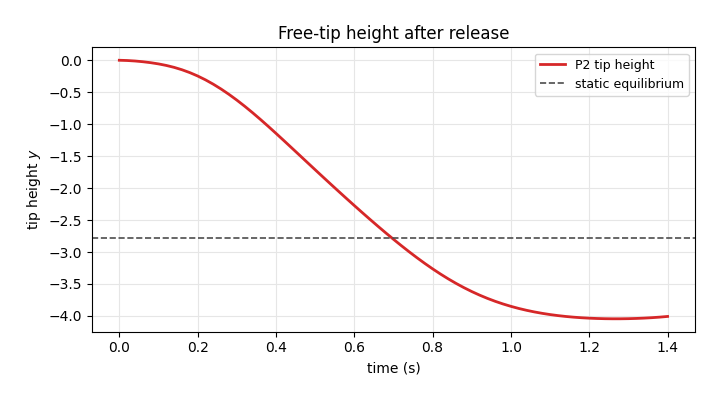

In [13]:
fig, ax = utils.line_plot(ts, {"P2 tip height": tip_y}, xlabel="time (s)", ylabel="tip height $y$",
                          colors={"P2 tip height": "#d62728"}, title="Free-tip height after release",
                          figsize=(7, 3.8))
ax.axhline(sol2[tip2, 1].mean(), color="0.3", ls="--", lw=1.2, label="static equilibrium")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "tip_trajectory.png"),
                              copy_to=os.path.join(MEDIA_DIR, "020_tip_trajectory.png"))
plt.show()

The video: the curved P2 surface as the beam falls (coarser face sampling for speed), over the faint
rest shape.

In [14]:
frame_polys = [curved_surface(U, W_video, ref_F_video) for U in frames]
frame_times = [f"t = {k * FRAME_STRIDE * DT:.2f} s" for k in range(len(frames))]
fig, anim = utils.animate_surface_y_up(frame_polys, lims=utils.auto_limits_3d(frames, pad=0.15),
                                       ghost_polys=curved_surface(V2, W_video, ref_F_video),
                                       title="P2 beam released under gravity (backward Euler)",
                                       fps=FPS, figsize=(6.4, 5.6), texts=frame_times, **VIEW)
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "p2_beam_fall.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "020_p2_beam_fall.mp4"))
plt.close(fig)
utils.embed_video(video)

## 6 &middot; P1 vs P2: same tets, very different bending

Finally we solve the identical static problem with ordinary **linear** tets on the same `(X, T)`, with
the same `beam_system` handed the P1 operators. A constant-strain tet cannot represent the linear strain
variation through the beam's height without also shearing, so coarse linear tets **lock**: they come out
far too stiff, and the tip barely moves.

In [15]:
energy_func, gradient_func, hessian_func = beam_system(**ops_p1)
x1, info1 = simkit.solvers.newton_solver(X.reshape(-1, 1).copy(), energy_func, gradient_func, hessian_func,
                                         max_iter=STATIC_ITERS, tolerance=STATIC_TOL, return_info=True)
sol1 = x1.reshape(n1, dim)
drop1 = X[tip1, 1].mean() - sol1[tip1, 1].mean()
print(f"P1 tip drop: {drop1:.3f}   ({n1 * dim} dofs, {info1['iters'] + 1} Newton iterations)")
print(f"P2 tip drop: {drop2:.3f}   ({n2 * dim} dofs, {info2['iters'] + 1} Newton iterations)")
print(f"P2 deflects {drop2 / drop1:.1f}x as far as P1 on the same tets")

P1 tip drop: 0.418   (135 dofs, 9 Newton iterations)
P2 tip drop: 2.787   (627 dofs, 114 Newton iterations)
P2 deflects 6.7x as far as P1 on the same tets


Validation: the gradient norm at every Newton iteration of both static solves. The locked P1 beam hardly
moves and converges in a few steps; the large, nonlinear P2 sag needs about 20 line-searched steps before
the gradient falls steadily. Both curves flatten near $10^{-4}$, about $10^{-6}$ of the pin forces. That is
a round-off floor: `quadratic_energy` omits the pin's constant $\tfrac12 K\lVert y\rVert^2$, so
$\Phi \approx -8\cdot 10^9$ (printed in section 4), and double precision cannot resolve the energy decrease
of a converged step; P2's line search stalls there until the step-size test stops it.

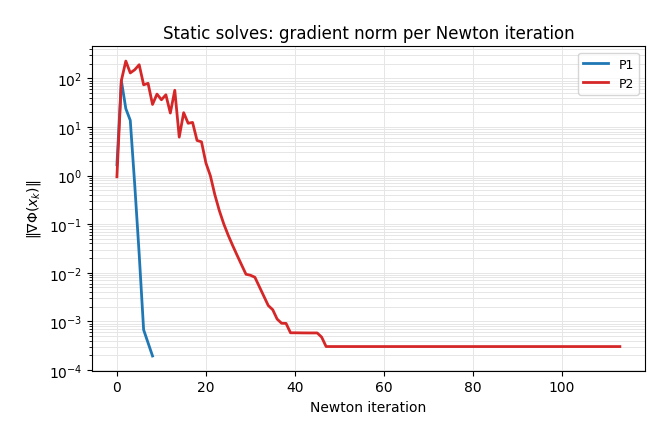

In [16]:
fig, ax = utils.residual_plot({"P1": [np.linalg.norm(g) for g in info1["g"]],
                               "P2": [np.linalg.norm(g) for g in info2["g"]]},
                              colors={"P1": "#1f77b4", "P2": "#d62728"}, stagger=False,
                              xlabel="Newton iteration", ylabel=r"$\|\nabla \Phi(x_k)\|$",
                              title="Static solves: gradient norm per Newton iteration")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "static_newton.png"),
                              copy_to=os.path.join(MEDIA_DIR, "020_static_newton.png"))
plt.show()

Side by side, same camera: P1 with its native flat faces, P2 with its curved faces.

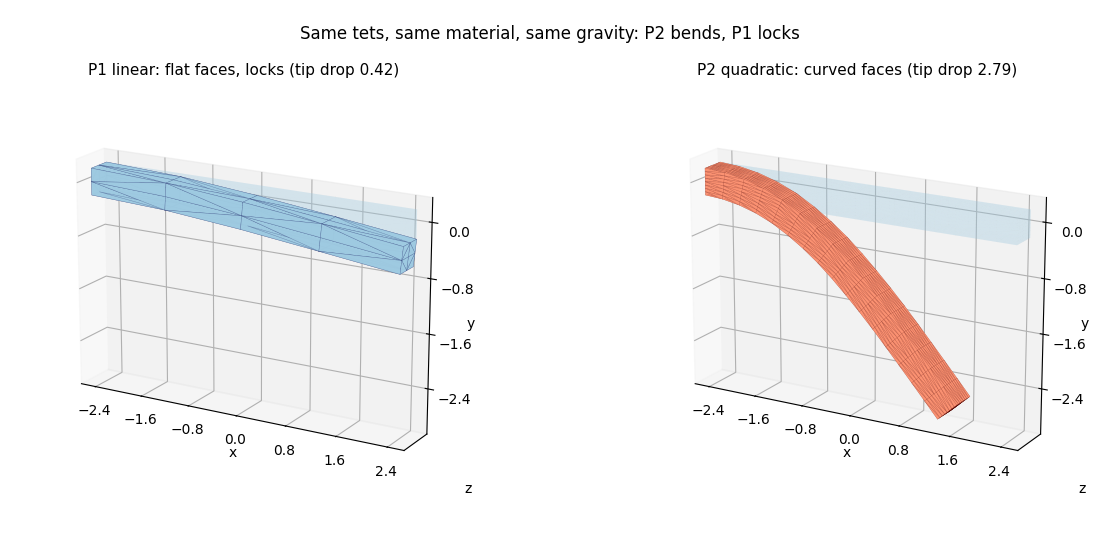

In [17]:
lims_cmp = utils.auto_limits_3d([X, sol1, sol2], pad=0.15)
fig = plt.figure(figsize=(13, 5.2))
ax = fig.add_subplot(121, projection="3d")
utils.surface_y_up(ax, X[F_bnd], facecolor=utils.MESH_FACE, edgecolor="none", alpha=0.2)
utils.surface_y_up(ax, sol1[F_bnd], facecolor="#9ecae1", edgecolor=(0, 0, 0.3, 0.35), lw=0.3, alpha=0.97)
utils.setup_axes_y_up(ax, lims_cmp, title=f"P1 linear: flat faces, locks (tip drop {drop1:.2f})", **VIEW)
ax = fig.add_subplot(122, projection="3d")
utils.surface_y_up(ax, curved_surface(V2, W_still, ref_F_still), facecolor=utils.MESH_FACE, edgecolor="none", alpha=0.2)
utils.surface_y_up(ax, curved_surface(sol2, W_still, ref_F_still), facecolor="#fc9272",
                   edgecolor=(0.3, 0, 0, 0.25), lw=0.25, alpha=0.97)
utils.setup_axes_y_up(ax, lims_cmp, title=f"P2 quadratic: curved faces (tip drop {drop2:.2f})", **VIEW)
fig.suptitle("Same tets, same material, same gravity: P2 bends, P1 locks", fontsize=12)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "p1_vs_p2_beam.png"),
                              copy_to=os.path.join(MEDIA_DIR, "020_p1_vs_p2_beam.png"))
plt.show()

## Takeaways

- The whole P2 stack (`linear_to_quadratic_elements`, `gauss_legendre_quadrature`, `deformation_jacobian_p2`,
  `p2_massmatrix`, `p2_gravity_force`) works on 3D tets exactly as on 2D triangles; a tet just has 10 nodes.
- P2 evaluates one $F$ per cubature point, so the energy becomes a cubature sum; the elastic energy, pin,
  inertia and Newton solver are the unchanged P1 code.
- The consistent P2 tet load pushes corner nodes *up* and midpoints down; only the total is $\rho g V$.
- On a bending-dominated cantilever, linear tets lock while the quadratic mesh deflects about 6.7x as far
  and renders with truly curved geometry.